# **CIFAR10 with ResNet18**



In [1]:
# Requirements: torch, torchvision, matplotlib, scikit-learn, tqdm

In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [19]:
%matplotlib inline


In [3]:
DATA_DIR = "./data"
BATCH_SIZE = 128
NUM_WORKERS = 4
NUM_EPOCHS = 40
LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
STEP_SIZE = 20            # LR scheduler step
GAMMA = 0.1
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [4]:
# dataset and dataloaders (augmentations for training)
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2023, 0.1994, 0.2010]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset  = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

# Optionally split train into train + val
val_ratio = 0.1
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(np.floor(val_ratio * num_train))
np.random.shuffle(indices)

train_idx, val_idx = indices[split:], indices[:split]
from torch.utils.data.sampler import SubsetRandomSampler
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_idx), num_workers=NUM_WORKERS)
val_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(val_idx), num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': len(train_idx), 'val': len(val_idx), 'test': len(test_dataset)}
class_names = train_dataset.classes
print("Classes:", class_names)
print("Dataset sizes:", dataset_sizes)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Dataset sizes: {'train': 45000, 'val': 5000, 'test': 10000}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
# model setup - ResNet18
use_pretrained = True

model = models.resnet18(pretrained=use_pretrained)

# modify first conv for CIFAR (optional). ResNet18 expects 224x224, but we can keep it and it will work.
# Two common approaches:
# 1) Replace conv1 to kernel_size=3, stride=1, padding=1 (recommended for CIFAR)
# 2) Keep original and upsample images to 224 (less common for CIFAR)

# Adjust conv1 for CIFAR:
model.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = torch.nn.Identity()  # remove the 7x7 maxpool (not needed)

# Replace final fc
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# training & validation loop with checkpointing and metric logging
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, checkpoint_dir="./checkpoints"):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        # Each epoch has training and validation
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            num_samples = 0

            loop = tqdm(dataloaders[phase], desc=f"{phase} epoch {epoch+1}", leave=False)
            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)
                batch_size = inputs.size(0)
                num_samples += batch_size

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * batch_size
                running_corrects += torch.sum(preds == labels.data).item()

            epoch_loss = running_loss / num_samples
            epoch_acc = running_corrects / num_samples

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

                # deep copy the model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save({'epoch': epoch+1,
                                'model_state_dict': model.state_dict(),
                                'optimizer_state_dict': optimizer.state_dict(),
                                'best_acc': best_acc},
                               os.path.join(checkpoint_dir, 'best_checkpoint.pth'))
                    print("Saved best model checkpoint.")

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1} completed in {epoch_time//60:.0f}m {epoch_time%60:.0f}s\n")

    print(f"Training complete. Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model, history


In [10]:
# training (this is where most time is spent)
best_model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, NUM_EPOCHS, CHECKPOINT_DIR)

# If you want to resume from checkpoint:
# checkpoint = torch.load('./checkpoints/best_checkpoint.pth')
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

Epoch 1/40
------------------------------


train Loss: 0.4705 Acc: 0.8384


val Loss: 0.3647 Acc: 0.8732
Saved best model checkpoint.
Epoch 1 completed in 0m 40s

Epoch 2/40
------------------------------


train Loss: 0.3172 Acc: 0.8906


val Loss: 0.3511 Acc: 0.8844
Saved best model checkpoint.
Epoch 2 completed in 0m 40s

Epoch 3/40
------------------------------


...

val Loss: 0.2050 Acc: 0.9468
Epoch 38 completed in 0m 39s

Epoch 39/40
------------------------------


train Loss: 0.0047 Acc: 0.9992


val Loss: 0.1900 Acc: 0.9510
Epoch 39 completed in 0m 39s

Epoch 40/40
------------------------------


train Loss: 0.0043 Acc: 0.9994


val Loss: 0.2003 Acc: 0.9496
Epoch 40 completed in 0m 39s

Training complete. Best val Acc: 0.9512


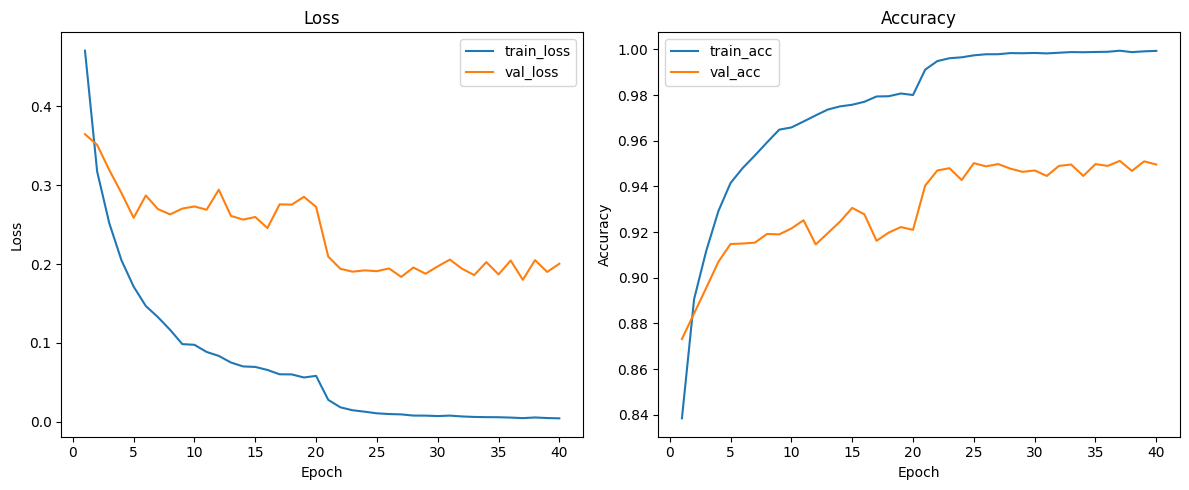

In [15]:
plot_training_history(history)


In [21]:
# plotting utilities (loss/accuracy curves)
def plot_training_history(history):
    epochs_train = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_train, history['train_loss'], label='train_loss')
    plt.plot(epochs_train, history['val_loss'], label='val_loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs_train, history['train_acc'], label='train_acc')
    plt.plot(epochs_train, history['val_acc'], label='val_acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.tight_layout()
    plt.show()

In [16]:
# evaluation on test set
def evaluate_model(model, dataloader, class_names):
    model.eval()
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    cm = confusion_matrix(labels_all, preds_all)

    print("\nClassification Report:")
    print(classification_report(labels_all, preds_all, target_names=class_names, digits=4))

    return cm, labels_all, preds_all


In [12]:
# confusion matrix + classification report

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    plt.figure(figsize=(8,8))
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


In [23]:
# visualize some predictions (de-normalize for display)
inv_transform = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

def imshow(img_tensor, ax=None, title=None):
    img = inv_transform(img_tensor).numpy().transpose((1,2,0))
    img = np.clip(img, 0, 1)
    if ax is None:
        plt.imshow(img)
        if title: plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(img)
        if title: ax.set_title(title)
        ax.axis('off')

def show_sample_predictions(model, dataloader, n=8):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(16,4))
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            bs = inputs.size(0)
            for i in range(bs):
                ax = plt.subplot(1, n, images_shown+1)
                imshow(inputs[i].cpu(), ax=ax, title=f"pred: {class_names[preds[i]]}\ntrue: {class_names[labels[i]]}")
                images_shown += 1
                if images_shown == n:
                    plt.show()
                    return
    plt.show()

In [28]:
def show_sample_predictions(model, dataloader, n=8):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(16, 4))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            bs = inputs.size(0)

            for i in range(bs):
                ax = plt.subplot(1, n, images_shown + 1)

                imshow(
                    inputs[i].cpu(),
                    ax=ax,
                    title=f"pred: {class_names[preds[i]]}\ntrue: {class_names[labels[i]]}"
                )

                images_shown += 1
                if images_shown == n:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()


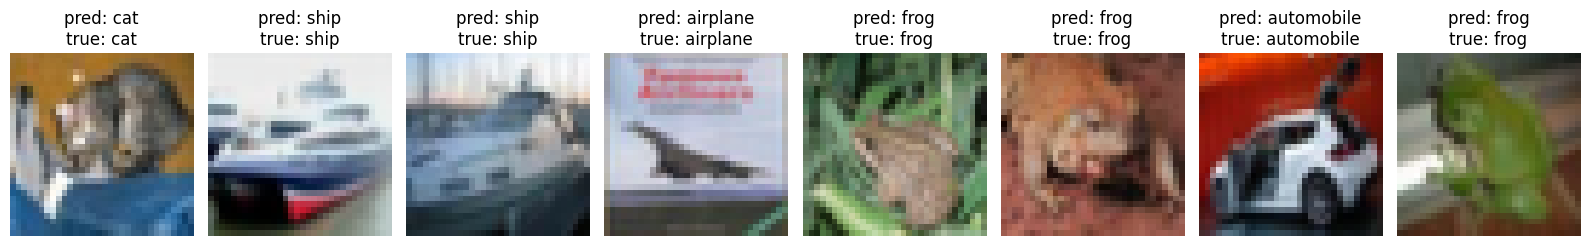

In [29]:
show_sample_predictions(best_model, dataloaders['test'], n=8)


In [17]:
cm, labels_all, preds_all = evaluate_model(
    best_model,
    dataloaders['test'],
    class_names
)


Evaluating: 100%|██████████| 79/79 [00:03<00:00, 21.51it/s]


Classification Report:
              precision    recall  f1-score   support

    airplane     0.9577    0.9520    0.9549      1000
  automobile     0.9702    0.9780    0.9741      1000
        bird     0.9395    0.9470    0.9432      1000
         cat     0.8867    0.8920    0.8893      1000
        deer     0.9422    0.9620    0.9520      1000
         dog     0.9300    0.9030    0.9163      1000
        frog     0.9635    0.9760    0.9697      1000
       horse     0.9735    0.9560    0.9647      1000
        ship     0.9624    0.9720    0.9672      1000
       truck     0.9737    0.9610    0.9673      1000

    accuracy                         0.9499     10000
   macro avg     0.9499    0.9499    0.9499     10000
weighted avg     0.9499    0.9499    0.9499     10000



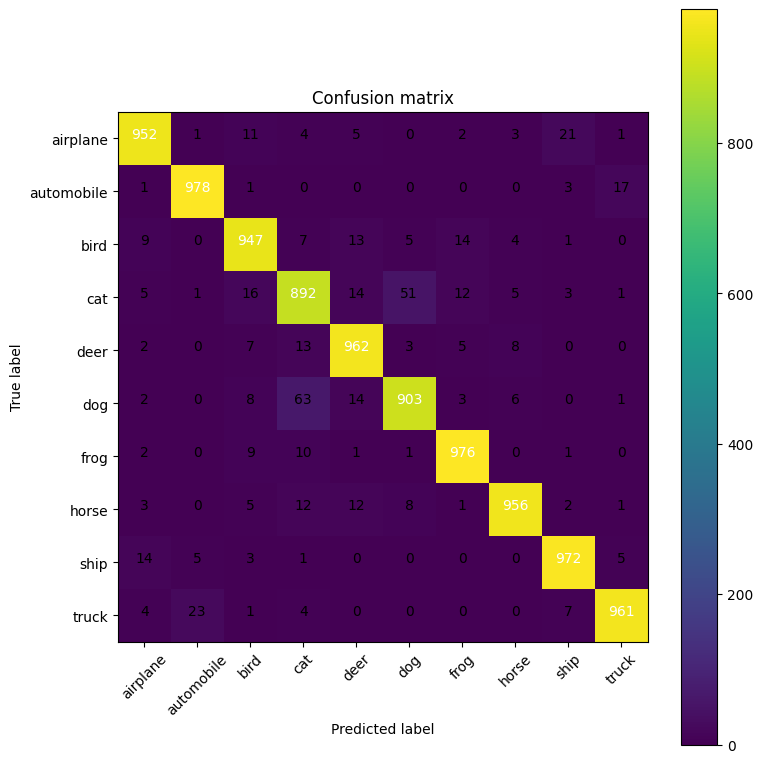

In [18]:
plot_confusion_matrix(cm, class_names)
